[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/takechanman1228/marketing-science-in-python/blob/main/notebooks/part5-commercial-analytics/sec5.2_assortment_optimization.ipynb)

# Product Assortment Optimization

This notebook accompanies **Chapter 5.2** of *Marketing Science in Python*.
We implement a focused assortment-rationalization workflow on real grocery
transaction data: screen SKUs by **revenue ABC**, then run a **substitution
check** (low same-sub-category Lift) to decide which low-revenue candidates
are safe to test for removal. Halo-effect detection serves as a guardrail to
flag candidates whose removal could hurt cross-category basket revenue.
Validation is left to a matched-store test (covered in the chapter prose).

**Note on revenue vs. margin.** This chapter uses **revenue** because the
public Dunnhumby dataset lacks product cost / COGS. The same workflow runs
on **gross margin** or **contribution margin** when costs are available —
only the business interpretation shifts (revenue-risk → margin
optimization). See the Key Takeaways at the end of the notebook.

**Learning objectives**

1. Screen SKUs by **revenue** using ABC analysis; the C-rank long tail is
   the candidate pool for rationalization.
2. For each candidate, run a substitution check: same-sub-category peers
   with low Lift (< 0.8) are plausible substitutes that can absorb demand.
3. Flag halo effects (cross-sub-category Lift > 1.3 with A/B-revenue
   products) as an "investigate before cutting" guardrail.
4. Produce a scored shortlist with one of three actions per candidate;
   validate any removal with a matched-store test before scaling.

**Dataset**: Dunnhumby — *The Complete Journey* (CC0 via Kaggle).
2-year grocery transactions from 2,500 households across multiple stores.

In [1]:
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Colab bootstrap: make the `msbook` helper package importable.
# Local / conda users already have it via `pip install -e .` from the repo root,
# so this is a no-op for them. On Colab it clones the book repo and installs
# msbook in editable mode. (A plain `pip install git+...` is not enough: msbook
# resolves paths by walking up to the repo root marker, so it needs the repo
# tree present, which the clone provides.)
import sys
try:
    import msbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess
    _REPO = "https://github.com/takechanman1228/marketing-science-in-python.git"
    subprocess.run(["git", "clone", "-q", _REPO], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    "marketing-science-in-python"], check=True)
    import msbook  # noqa: F401
from msbook.paths import chapter_images, chapter_artifacts

_FIG_DIR = chapter_images(part="5", chapter="sec5.2")

# Scratch tables (ABC summary / decision matrix / substitution results).
# Written under artifacts/, which is not committed: they are intermediate
# output, not results the chapter quotes.
_TABLES_DIR = chapter_artifacts(part="5", chapter="sec5.2-assortment") / "tables"
_TABLES_DIR.mkdir(parents=True, exist_ok=True)


def savefig(fig, name, **kw):
    kw.setdefault("dpi", 150)
    kw.setdefault("bbox_inches", "tight")
    fig.savefig(_FIG_DIR / name, **kw)

# `display` is provided by IPython/Jupyter; fall back to print so this runs
# as a plain script too.
try:
    display
except NameError:
    display = print

# ── All tuneable parameters in one place ──────────────────────────────────
CONFIG = {
    # Data paths
    "data_dir": "../../data/raw/Dunnhumby_kaggle",
    "kaggle_dataset": "frtgnn/dunnhumby-the-complete-journey",
    # Department filter
    "department": "GROCERY",
    # Revenue ABC thresholds (cumulative share breakpoints)
    "abc_bins": [0, 0.80, 0.95, 1.0],
    "abc_labels": ["A", "B", "C"],
    # Basket analysis. The analysis universe is the union of three pools (top
    # candidates + top context/A-B products + same-subcategory peers), not a
    # single "top-N" list.
    "top_n_candidate_products": 100,  # top low-revenue candidates (by basket freq) to score
    "top_n_context_products": 100,    # top A/B context SKUs (substitution + halo universe)
    "substitution_lift": 0.8,       # Lift < this = substitution signal
    # Halo guardrail. Keep a high bar so only the clearest cross-category
    # cases are flagged; a weak halo signal is not worth acting on.
    "halo_lift": 1.3,               # Lift > this = halo signal
    "halo_min_confidence": 0.01,    # minimum confidence for halo rules
    "strong_halo_lift": 15.0,       # halo flag needs max lift >= this ...
    "strong_halo_min_count": 30,    # ... AND at least this many halo partners (both required)
    # Substitution: require multiple A/B-revenue substitutes before trusting
    # that demand can be absorbed when a C-rank SKU is removed.
    "min_substitutes_for_test": 5,
}

pd.set_option("display.float_format", "{:.2f}".format)
%config InlineBackend.figure_format = "retina"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. Data Loading & Preprocessing

In [4]:
import pathlib

data_dir = pathlib.Path(CONFIG["data_dir"])

if not (data_dir / "transaction_data.csv").exists():
    # Fallback: download via kagglehub
    try:
        import kagglehub
        downloaded = kagglehub.dataset_download(CONFIG["kaggle_dataset"])
        data_dir = pathlib.Path(downloaded)
        print(f"Downloaded to {data_dir}")
    except Exception as e:
        raise FileNotFoundError(
            f"Data not found at {data_dir}. Download from Kaggle: "
            f"https://www.kaggle.com/datasets/{CONFIG['kaggle_dataset']}\n"
            f"Error: {e}"
        )

# Load the two tables we need: transactions + product metadata.
transactions = pd.read_csv(data_dir / "transaction_data.csv")
products = pd.read_csv(data_dir / "product.csv")

print(f"Transactions: {len(transactions):,} rows")
print(f"Products:     {len(products):,} rows")
print(f"\nWeek range: {transactions['WEEK_NO'].min()} – {transactions['WEEK_NO'].max()}")
print(f"Stores: {transactions['STORE_ID'].nunique()}")

Transactions: 2,595,732 rows
Products:     92,353 rows

Week range: 1 – 102
Stores: 582


In [5]:
# Merge transactions with product metadata
df = transactions.merge(products, on="PRODUCT_ID", how="left")

# Filter to GROCERY department for tractable basket analysis
df = df[df["DEPARTMENT"] == CONFIG["department"]].copy()
print(f"After filtering to {CONFIG['department']}: {len(df):,} rows")
print(f"Unique products: {df['PRODUCT_ID'].nunique():,}")
print(f"Unique sub-categories: {df['SUB_COMMODITY_DESC'].nunique()}")

After filtering to GROCERY: 1,646,076 rows
Unique products: 39,019
Unique sub-categories: 736


In [6]:
# Build SKU-level summary. We deliberately omit a "gross margin" column:
# the dataset has no product cost, so SALES_VALUE − discounts would still
# be revenue, not margin. See the caveat at the top of this notebook.
sku_summary = (
    df.groupby("PRODUCT_ID")
    .agg(
        revenue=("SALES_VALUE", "sum"),
        units=("QUANTITY", "sum"),
        n_baskets=("BASKET_ID", "nunique"),
        n_stores=("STORE_ID", "nunique"),
        n_weeks=("WEEK_NO", "nunique"),
    )
    .reset_index()
)

# Attach product metadata
sku_summary = sku_summary.merge(
    products[["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC", "BRAND"]],
    on="PRODUCT_ID",
    how="left",
)

print(f"SKU summary: {len(sku_summary):,} products")
print(f"Total revenue: ${sku_summary['revenue'].sum():,.0f}")
print(f"Total baskets: {df['BASKET_ID'].nunique():,}")
display(sku_summary.sort_values("revenue", ascending=False).head(10))

SKU summary: 39,019 products
Total revenue: $4,093,814
Total baskets: 215,411


,PRODUCT_ID,revenue,units,n_baskets,n_stores,n_weeks,DEPARTMENT,COMMODITY_DESC,SUB_COMMODITY_DESC,BRAND
14421,1029743,41072.06,16976,14430,115,102,GROCERY,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,Private
18231,1106523,27818.44,11500,9826,115,102,GROCERY,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,Private
12738,995242,26502.46,21758,12542,115,102,GROCERY,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,Private
27153,5569230,23651.56,7682,4834,114,102,GROCERY,SOFT DRINKS,SOFT DRINKS 12/18&15PK CAN CAR,National
19501,1133018,14942.36,12318,7315,115,101,GROCERY,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,Private
19193,1126899,13435.30,5496,4484,110,102,GROCERY,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,Private
27166,5569471,12863.07,4356,2221,109,101,GROCERY,SOFT DRINKS,SOFT DRINKS 12/18&15PK CAN CAR,National
16442,1070820,12441.07,5163,4440,109,102,GROCERY,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,Private
10622,951590,12385.27,7648,6138,113,102,GROCERY,BAKED BREAD/BUNS/ROLLS,MAINSTREAM WHITE BREAD,National
12072,981760,11693.65,11229,9126,114,102,GROCERY,EGGS,EGGS - X-LARGE,Private


## 2. Step 1 — Revenue ABC Classification

Rank SKUs by **revenue** (how much money each SKU brings in) using a
Pareto-style ABC cut. **Low-revenue SKUs** (`abc_revenue == "C"`) form the
candidate pool for rationalization: the long tail that, individually, brings
in very little. Revenue gets a SKU into the pool; the substitution check in
Step 2 decides whether it is safe to test for removal.

In [7]:
def revenue_abc(
    sku_summary: pd.DataFrame, config: dict = CONFIG, verbose: bool = True
) -> pd.DataFrame:
    """
    Assign ABC ranks on **revenue**.

    SKUs with zero or negative revenue (or zero baskets) are filtered out
    before ABC is computed — they are out of scope for assortment
    rationalization (no sales = no assortment decision to make).

    Parameters
    ----------
    sku_summary : DataFrame with columns ['PRODUCT_ID', 'revenue', 'n_baskets']
    config : dict with 'abc_bins' and 'abc_labels'
    verbose : if True, print how many SKUs were filtered out and why

    Returns
    -------
    DataFrame with an added column: 'abc_revenue'.
    Rows with revenue <= 0 or n_baskets <= 0 are NOT present in the output.
    """
    n_in = len(sku_summary)
    keep_mask = (sku_summary["revenue"] > 0) & (sku_summary["n_baskets"] > 0)
    n_dropped = int((~keep_mask).sum())

    if verbose and n_dropped:
        # Counts by reason, for transparency in the print log.
        only_rev = ((sku_summary["revenue"] <= 0) & (sku_summary["n_baskets"] > 0)).sum()
        only_bsk = ((sku_summary["revenue"] > 0) & (sku_summary["n_baskets"] <= 0)).sum()
        both = ((sku_summary["revenue"] <= 0) & (sku_summary["n_baskets"] <= 0)).sum()
        print(
            f"revenue_abc: filtered {n_dropped} / {n_in} SKUs with no sales "
            f"(only revenue<=0: {only_rev}, only n_baskets<=0: {only_bsk}, both: {both})."
        )

    result = sku_summary.loc[keep_mask].copy()

    for metric, col_name in [
        ("revenue", "abc_revenue"),
    ]:
        sorted_df = result.sort_values(metric, ascending=False)
        # Classify on the cumulative share *before* each SKU: the SKU that
        # crosses the 80% line is still needed to reach 80% (rank A), and a
        # single SKU holding >80% of revenue can never fall out of A. (The
        # inclusive cumulative would push the boundary SKU down a rank.)
        cum_before = (
            sorted_df[metric].cumsum() / sorted_df[metric].sum()
        ).shift(fill_value=0.0)
        sorted_df[col_name] = pd.cut(
            cum_before,
            bins=config["abc_bins"],
            labels=config["abc_labels"],
            right=False,           # [0, .80), [.80, .95), [.95, 1.0)
        )
        # In case pd.cut returns NaN at a boundary edge (very rare), fall
        # back to the most conservative label "C" so the output table
        # never contains NaN ranks.
        sorted_df[col_name] = sorted_df[col_name].astype(object).fillna("C")
        result[col_name] = sorted_df[col_name]

    # Guarantee: no NaN labels in the output table.
    assert result["abc_revenue"].notna().all(), "abc_revenue has NaN"
    return result


sku_summary = revenue_abc(sku_summary)
sku_summary.to_csv(
    _TABLES_DIR / "assortment_revenue_sku_summary.csv", index=False
)

# Candidate pool: low-revenue SKUs (the chapter's "long tail").
candidates = sku_summary[sku_summary["abc_revenue"] == "C"].copy()
print(
    f"Low-revenue candidate pool: {len(candidates):,} SKUs "
    f"({len(candidates)/len(sku_summary)*100:.0f}% of assortment, "
    f"{candidates['revenue'].sum()/sku_summary['revenue'].sum()*100:.1f}% of revenue)"
)

revenue_abc: filtered 38 / 39019 SKUs with no sales (only revenue<=0: 38, only n_baskets<=0: 0, both: 0).
Low-revenue candidate pool: 24,671 SKUs (63% of assortment, 5.0% of revenue)


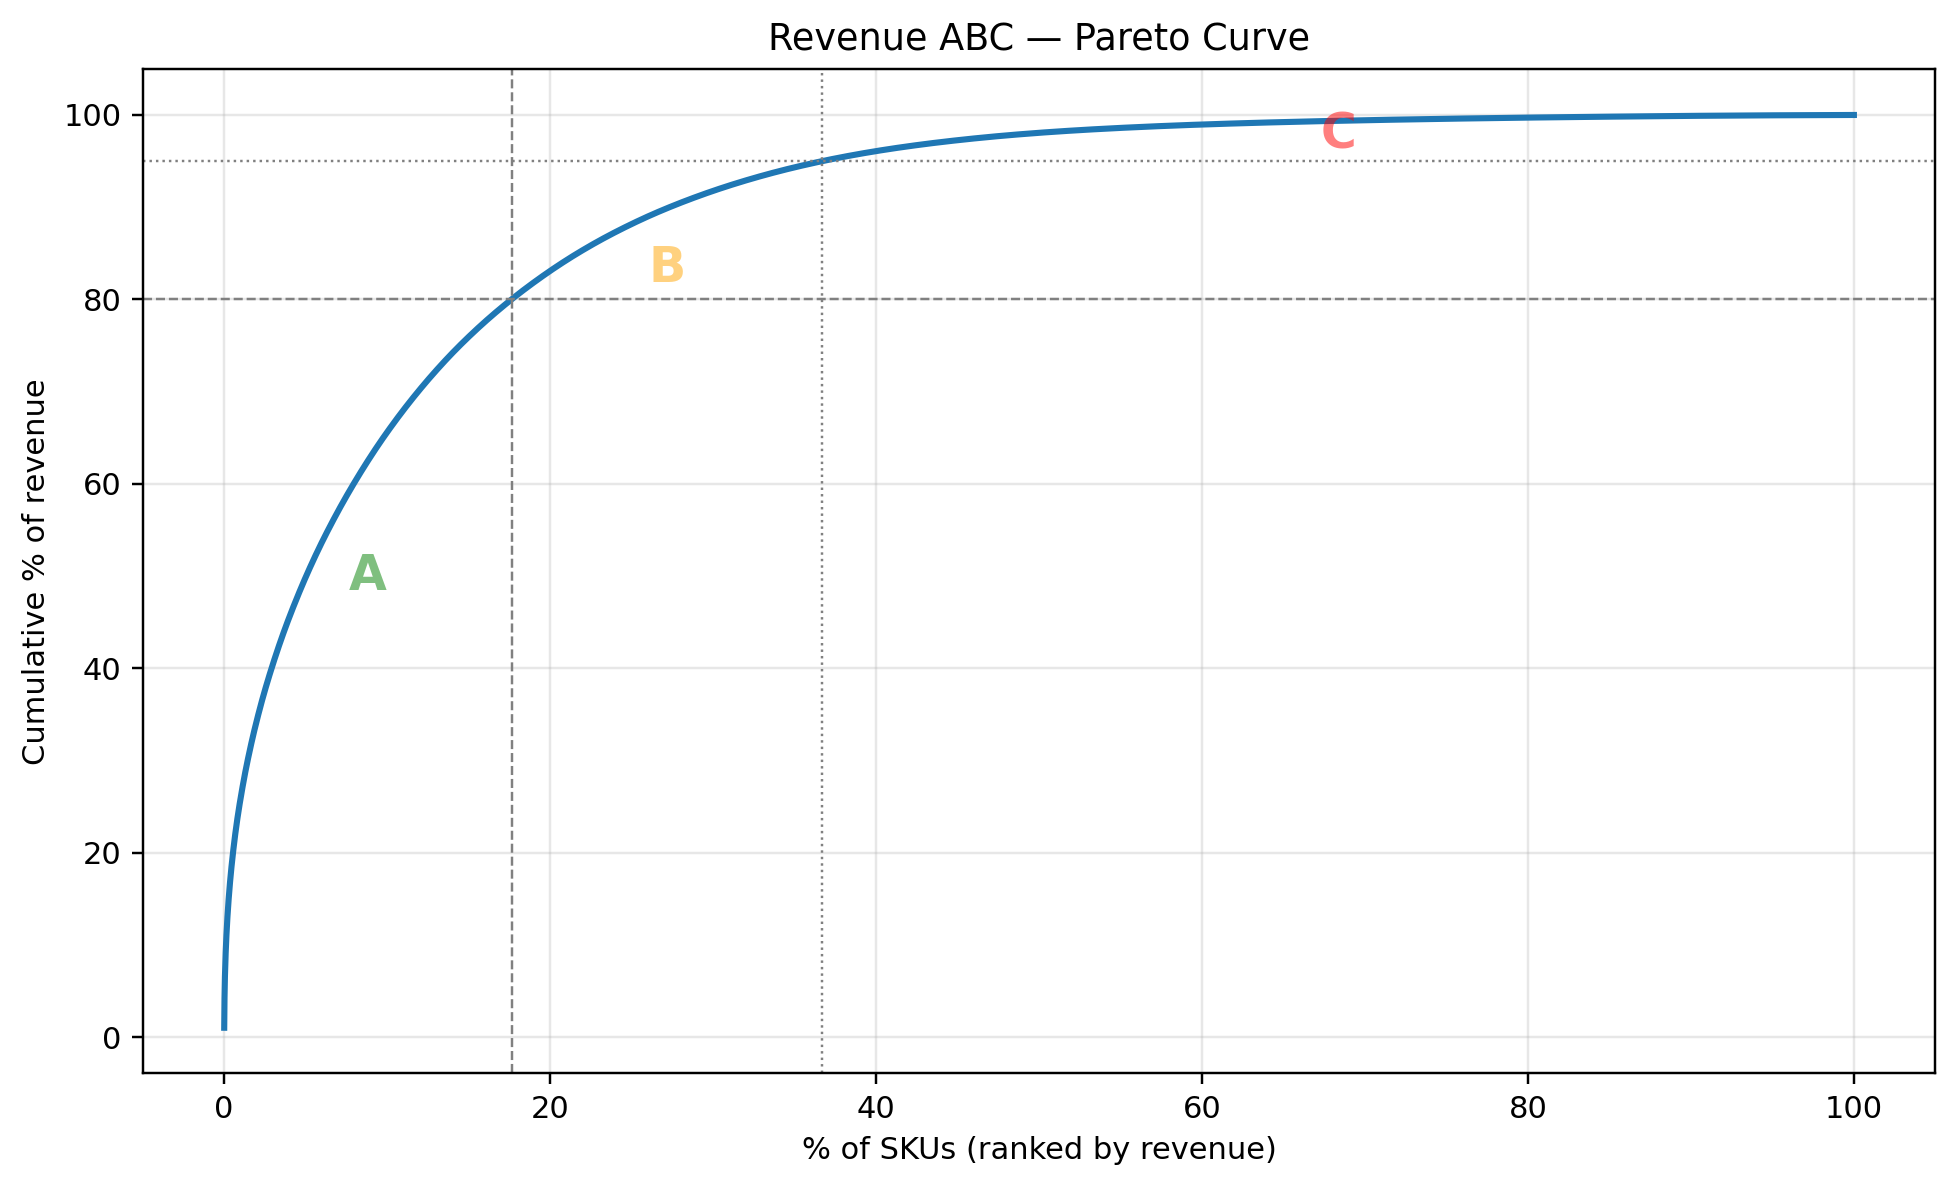

In [8]:
# Visualization: revenue Pareto curve
fig, ax = plt.subplots(figsize=(9, 5.5))

sorted_vals = sku_summary["revenue"].sort_values(ascending=False).values
cum_share = np.cumsum(sorted_vals) / sorted_vals.sum()
sku_share = np.arange(1, len(cum_share) + 1) / len(cum_share)

ax.plot(sku_share * 100, cum_share * 100, linewidth=2)
# ABC boundaries (80% / 95% cumulative revenue)
boundaries = []
for pct, style in [(80, "--"), (95, ":")]:
    ax.axhline(pct, color="grey", linestyle=style, linewidth=0.8)
    idx = np.searchsorted(cum_share, pct / 100)
    boundaries.append(sku_share[min(idx, len(sku_share) - 1)] * 100)
    ax.axvline(boundaries[-1], color="grey", linestyle=style, linewidth=0.8)

ax.set_xlabel("% of SKUs (ranked by revenue)")
ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Revenue ABC — Pareto Curve")

# Each letter sits in the middle of the SKU range its class actually covers,
# and just under the curve at that point. Fixed coordinates would drift the
# moment the assortment changes shape, and here A and B are both narrow: most
# of the x-axis is C.
x_ab, x_bc = boundaries
for label, x_lo, x_hi, drop, color in [
    ("A", 0.0, x_ab, 14, "green"),
    ("B", x_ab, x_bc, 8, "orange"),
    ("C", x_bc, 100.0, 3, "red"),
]:
    x_mid = (x_lo + x_hi) / 2
    y_mid = np.interp(x_mid, sku_share * 100, cum_share * 100) - drop
    ax.text(x_mid, y_mid, label, fontsize=16, color=color,
            fontweight="bold", alpha=0.5, ha="center")

fig.tight_layout()
savefig(fig, "revenue_pareto_curve.png")
plt.show()

## 3. Step 2 — Substitution Analysis

For each low-revenue candidate, identify substitutes: products in the
**same sub-category** with **Lift < 0.8**, meaning customers treat them
as alternatives (buy one OR the other, rarely both).

In [9]:
# Build basket-level product sets for co-occurrence analysis.
# Strategy: include top A/B-rank products (halo targets) plus
# low-revenue candidates plus same-subcategory peers (substitution targets).

product_freq = df.groupby("PRODUCT_ID")["BASKET_ID"].nunique().sort_values(ascending=False)

# A/B context products - top by basket frequency (substitution + halo universe)
top_ab = set(product_freq.nlargest(CONFIG["top_n_context_products"]).index)

# Low-revenue candidates with >= 30 baskets, top by basket frequency
candidate_freq = product_freq[product_freq.index.isin(candidates["PRODUCT_ID"])]
top_candidates = set(candidate_freq[candidate_freq >= 30].nlargest(CONFIG["top_n_candidate_products"]).index)

# Same-subcategory peers for each candidate (substitution targets).
# Include non-candidate products in the same sub-categories as candidates.
candidate_subcats = set(
    products.loc[products["PRODUCT_ID"].isin(top_candidates), "SUB_COMMODITY_DESC"].dropna()
)
subcat_peers = set(
    products.loc[
        products["SUB_COMMODITY_DESC"].isin(candidate_subcats)
        & products["PRODUCT_ID"].isin(product_freq[product_freq >= 30].index),
        "PRODUCT_ID"
    ]
)

top_products = top_ab | top_candidates | subcat_peers
print(f"A/B-rank products (top by basket frequency): {len(top_ab)}")
print(f"Low-revenue candidates (>= 30 baskets):       {len(top_candidates)}")
print(f"Same-subcategory peers:                       {len(subcat_peers)}")
print(f"Combined product set:                         {len(top_products)}")

# Pre-compute basket membership for each product (for pairwise lift)
basket_sets = {}
for pid in top_products:
    basket_sets[pid] = set(
        df.loc[df["PRODUCT_ID"] == pid, "BASKET_ID"].unique()
    )

total_baskets = df["BASKET_ID"].nunique()
print(f"Total baskets in GROCERY: {total_baskets:,}")
print(f"Low-revenue candidates in analysis set: "
      f"{len(candidates[candidates['PRODUCT_ID'].isin(top_products)])}")

A/B-rank products (top by basket frequency): 100
Low-revenue candidates (>= 30 baskets):       100
Same-subcategory peers:                       1087
Combined product set:                         1164


Total baskets in GROCERY: 215,411
Low-revenue candidates in analysis set: 150


In [10]:
# Compute pairwise Lift directly from basket co-occurrence.
# Lift(A->B) = P(A and B) / (P(A) * P(B))
# This works for sparse C-rank products where FP-Growth's support
# threshold would filter them out.
#
# We compute two sets of pairs:
# 1. Substitution pairs: candidate x same-subcategory product (any rank)
# 2. Halo pairs: candidate x A/B-rank product (different subcategory)

subcat_map = products.set_index("PRODUCT_ID")["SUB_COMMODITY_DESC"].to_dict()
candidate_ids_in_set = set(candidates["PRODUCT_ID"]) & top_products
ab_ids_in_set = top_ab & top_products

# Group products by sub-category for efficient same-subcat lookups
from collections import defaultdict
subcat_to_products = defaultdict(set)
for pid in top_products:
    sc = subcat_map.get(pid)
    if sc:
        subcat_to_products[sc].add(pid)

rules_rows = []
for ant_id in candidate_ids_in_set:
    ant_baskets = basket_sets.get(ant_id, set())
    if len(ant_baskets) < 10:
        continue
    p_ant = len(ant_baskets) / total_baskets
    ant_subcat = subcat_map.get(ant_id, "")

    # Consequent candidates: same-subcategory peers + A/B-rank products
    consequent_ids = set()
    if ant_subcat:
        consequent_ids |= subcat_to_products.get(ant_subcat, set())
    consequent_ids |= ab_ids_in_set
    consequent_ids.discard(ant_id)

    for con_id in consequent_ids:
        con_baskets = basket_sets.get(con_id, set())
        if len(con_baskets) < 10:
            continue

        co_occur = len(ant_baskets & con_baskets)
        if co_occur < 2:
            continue

        p_con = len(con_baskets) / total_baskets
        p_both = co_occur / total_baskets
        lift = p_both / (p_ant * p_con) if (p_ant * p_con) > 0 else 0
        confidence = co_occur / len(ant_baskets)

        rules_rows.append({
            "antecedent": ant_id,
            "consequent": con_id,
            "lift": round(lift, 3),
            "confidence": round(confidence, 4),
            "support": round(p_both, 6),
            "co_occurrences": co_occur,
        })

rules = pd.DataFrame(rules_rows)
if rules.empty:
    # Ensure expected columns exist even when no rules were generated
    rules = pd.DataFrame(columns=["antecedent", "consequent", "lift",
                                   "confidence", "support", "co_occurrences"])
print(f"Pairwise rules computed: {len(rules):,}")
print(f"Rules with Lift < {CONFIG['substitution_lift']} (substitution signal): "
      f"{(rules['lift'] < CONFIG['substitution_lift']).sum()}")
print(f"Rules with Lift > {CONFIG['halo_lift']} (halo signal): "
      f"{(rules['lift'] > CONFIG['halo_lift']).sum()}")

Pairwise rules computed: 5,345
Rules with Lift < 0.8 (substitution signal): 23
Rules with Lift > 1.3 (halo signal): 5184


In [11]:
def build_substitution_map(
    rules_df: pd.DataFrame,
    candidates: pd.DataFrame,
    products_meta: pd.DataFrame,
    basket_sets: dict,
    total_baskets: int,
    sku_summary: pd.DataFrame = None,
    config: dict = CONFIG,
) -> dict:
    """
    Identify substitutes for each candidate SKU.

    A substitute is a product in the same sub-category with Lift < threshold.
    Only **A/B-revenue peers** qualify — a peer that is C-rank on revenue
    lacks the volume to absorb a removed candidate's redirected demand.

    Parameters
    ----------
    rules_df : DataFrame with 'antecedent', 'consequent', 'lift' columns
    candidates : DataFrame of candidate SKUs (must have 'PRODUCT_ID')
    products_meta : product metadata with 'PRODUCT_ID', 'SUB_COMMODITY_DESC'
    basket_sets : dict mapping PRODUCT_ID -> set of BASKET_IDs
    total_baskets : total number of baskets
    sku_summary : DataFrame with 'PRODUCT_ID', 'abc_revenue'
                  for absorb-capacity filtering
    config : dict with 'substitution_lift' threshold

    Returns
    -------
    dict: {candidate_product_id: [{"substitute": id, "lift": float,
                                   "subcategory": str, "method": str}, ...]}
    """
    subcat_map_local = products_meta.set_index("PRODUCT_ID")["SUB_COMMODITY_DESC"].to_dict()
    candidate_ids = set(candidates["PRODUCT_ID"])

    # A/B-revenue products that can absorb redirected demand — large enough
    # by revenue volume to take on a removed candidate's demand.
    ab_rank_ids = set()
    if sku_summary is not None:
        ab_rank_ids = set(
            sku_summary[
                sku_summary["abc_revenue"].isin(["A", "B"])
            ]["PRODUCT_ID"]
        )

    # Build rules lookup: (antecedent, consequent) -> lift
    rule_lookup = {}
    if len(rules_df) > 0:
        for _, rule in rules_df.iterrows():
            rule_lookup[(rule["antecedent"], rule["consequent"])] = rule["lift"]

    # Group all products in our analysis set by sub-category
    subcat_groups = defaultdict(set)
    for pid in basket_sets:
        sc = subcat_map_local.get(pid, "")
        if sc:
            subcat_groups[sc].add(pid)

    substitution_map = {}

    for cand_id in candidate_ids & set(basket_sets.keys()):
        cand_subcat = subcat_map_local.get(cand_id, "")
        if not cand_subcat:
            continue

        cand_baskets = basket_sets.get(cand_id, set())
        if len(cand_baskets) < 5:
            continue

        peers = subcat_groups.get(cand_subcat, set()) - {cand_id}
        # Only A/B-rank peers qualify as substitutes
        if ab_rank_ids:
            peers = peers & ab_rank_ids
        if not peers:
            continue

        subs = []
        for peer_id in peers:
            peer_baskets = basket_sets.get(peer_id, set())
            if len(peer_baskets) < 5:
                continue

            # Check if we have a computed lift
            pair_lift = rule_lookup.get((cand_id, peer_id))

            if pair_lift is not None and pair_lift < config["substitution_lift"]:
                subs.append({
                    "substitute": peer_id,
                    "lift": round(pair_lift, 3),
                    "subcategory": cand_subcat,
                    "method": "lift",
                })
            elif pair_lift is None:
                # No co-occurrence at all -> strong substitution signal
                co_occur = len(cand_baskets & peer_baskets)
                if co_occur == 0:
                    subs.append({
                        "substitute": peer_id,
                        "lift": 0.0,
                        "subcategory": cand_subcat,
                        "method": "zero_cooccurrence",
                    })
                else:
                    # Compute lift on the fly
                    p_cand = len(cand_baskets) / total_baskets
                    p_peer = len(peer_baskets) / total_baskets
                    p_both = co_occur / total_baskets
                    calc_lift = p_both / (p_cand * p_peer) if (p_cand * p_peer) > 0 else 0
                    if calc_lift < config["substitution_lift"]:
                        subs.append({
                            "substitute": peer_id,
                            "lift": round(calc_lift, 3),
                            "subcategory": cand_subcat,
                            "method": "lift",
                        })

        if subs:
            substitution_map[cand_id] = subs

    return substitution_map


substitution_map = build_substitution_map(
    rules, candidates, products, basket_sets, total_baskets,
    sku_summary=sku_summary,
)

print(f"Candidates with substitutes: {len(substitution_map)} / "
      f"{len(candidates[candidates['PRODUCT_ID'].isin(top_products)])} "
      f"(among analyzed products)")

# Show examples
sub_rows = []
for pid, subs in list(substitution_map.items())[:8]:
    for s in subs[:2]:
        sub_rows.append({
            "Candidate": pid,
            "Substitute": s["substitute"],
            "Lift": s["lift"],
            "Method": s["method"],
            "Sub-category": s["subcategory"],
        })
if sub_rows:
    display(pd.DataFrame(sub_rows))
else:
    print("No substitution pairs found.")

Candidates with substitutes: 148 / 150 (among analyzed products)


,Candidate,Substitute,Lift,Method,Sub-category
0,12757506,924165,0.00,zero_cooccurrence,POTATO CHIPS
1,12757506,7441927,0.00,zero_cooccurrence,POTATO CHIPS
2,870403,13876869,0.00,zero_cooccurrence,CAN CATFD GOURMET/SUP PREM (GR
3,870403,939539,0.00,zero_cooccurrence,CAN CATFD GOURMET/SUP PREM (GR
4,1015815,846241,0.00,zero_cooccurrence,VALUE
5,1015815,1029915,0.00,zero_cooccurrence,VALUE
6,27658,1048462,0.00,zero_cooccurrence,MAINSTREAM WHITE BREAD
7,27658,929433,0.00,zero_cooccurrence,MAINSTREAM WHITE BREAD
8,819727,850944,0.00,zero_cooccurrence,CAN CATFD GOURMET/SUP PREM (GR
9,819727,13876869,0.00,zero_cooccurrence,CAN CATFD GOURMET/SUP PREM (GR


## 4. Action Assignment

Combine the substitution check with a lightweight **halo** guardrail to
assign each candidate one of three actions. A halo exists when a candidate
co-occurs with A/B-**revenue** products across a **different** sub-category
at Lift > 1.3: removing it risks losing not just its own sales but the
complementary basket revenue it helps drive, so it goes to "investigate
before cutting". Halo takes priority over substitution.

In [12]:
def detect_halo_effects(
    rules_df: pd.DataFrame,
    candidates: pd.DataFrame,
    sku_summary: pd.DataFrame,
    products_meta: pd.DataFrame,
    config: dict = CONFIG,
) -> dict:
    """
    Identify candidates with halo effects on higher-rank products.

    A halo exists when a candidate co-occurs with **A/B-revenue** products
    at Lift > threshold in a *different* sub-category.

    Returns
    -------
    dict: {candidate_id: [
        {"halo_product": id, "lift": float, "halo_revenue_rank": str},
        ...
    ]}
    """
    subcat_map = products_meta.set_index("PRODUCT_ID")["SUB_COMMODITY_DESC"].to_dict()
    rev_rank_map = sku_summary.set_index("PRODUCT_ID")["abc_revenue"].to_dict()

    candidate_ids = set(candidates["PRODUCT_ID"])
    high_rank_ids = set(
        sku_summary[
            sku_summary["abc_revenue"].isin(["A", "B"])
        ]["PRODUCT_ID"]
    )

    halo_map = {}

    for _, rule in rules_df.iterrows():
        ant = rule["antecedent"]
        con = rule["consequent"]

        if ant not in candidate_ids:
            continue
        if con not in high_rank_ids:
            continue
        if rule["lift"] <= config["halo_lift"]:
            continue
        if rule["confidence"] < config["halo_min_confidence"]:
            continue

        # Must be different sub-category
        if subcat_map.get(ant, "") == subcat_map.get(con, ""):
            continue

        halo_map.setdefault(ant, []).append({
            "halo_product": con,
            "lift": round(rule["lift"], 2),
            "halo_revenue_rank": rev_rank_map.get(con, "?"),
        })

    return halo_map


halo_map = detect_halo_effects(rules, candidates, sku_summary, products)

print(f"Candidates with halo effects: {len(halo_map)}")

halo_rows = []
for pid, halos in list(halo_map.items())[:5]:
    for h in halos[:2]:
        halo_rows.append({
            "Candidate": pid,
            "Halo Product": h["halo_product"],
            "Lift": h["lift"],
            "Halo Revenue Rank": h["halo_revenue_rank"],
        })
if halo_rows:
    display(pd.DataFrame(halo_rows))
else:
    print("No strong halo effects found at current thresholds.")

Candidates with halo effects: 147


,Candidate,Halo Product,Lift,Halo Revenue Rank
0,12757506.00,1106523.00,1.57,A
1,12757506.00,962229.00,3.51,A
2,870403.00,1022003.00,6.94,A
3,870403.00,1013321.00,6.30,A
4,1015815.00,981760.00,2.20,A
5,1015815.00,833025.00,5.55,A
6,819727.00,833025.00,3.32,A
7,819727.00,1106523.00,5.94,A
8,891410.00,1022003.00,9.37,A
9,891410.00,1013321.00,14.18,A


In [13]:
# Score the candidates in the analysis set: substitution + halo flags -> action bucket
candidate_top = candidates[candidates["PRODUCT_ID"].isin(top_products)].copy()

# In dense grocery data, almost every C-rank product has at least one A/B
# peer in the same sub-category with zero co-occurrence.  A single distant
# peer is not a reliable substitute — we require MULTIPLE A/B-revenue
# substitutes to be confident that demand can be absorbed.
strong_sub_ids = set()
for pid, subs in substitution_map.items():
    if len(subs) >= CONFIG["min_substitutes_for_test"]:
        strong_sub_ids.add(pid)

candidate_top["has_substitute"] = candidate_top["PRODUCT_ID"].isin(strong_sub_ids)

# Halo scoring: flag only the *clearest* cases (the prose's high bar).
# A halo flag requires max_lift >= strong_halo_lift AND count >= strong_halo_min_count
# (a deliberately high bar: the prose treats halo as a rare "clearest cases" guardrail).
halo_strength = {}
for pid, halos in halo_map.items():
    lifts = [h["lift"] for h in halos]
    halo_strength[pid] = {
        "halo_max_lift": max(lifts),
        "halo_count": len(halos),
    }

if halo_strength:
    halo_strength_df = pd.DataFrame.from_dict(halo_strength, orient="index")
    candidate_top = candidate_top.merge(
        halo_strength_df, left_on="PRODUCT_ID", right_index=True, how="left"
    )
else:
    candidate_top["halo_max_lift"] = 0.0
    candidate_top["halo_count"] = 0

candidate_top["halo_max_lift"] = candidate_top["halo_max_lift"].fillna(0)
candidate_top["halo_count"] = candidate_top["halo_count"].fillna(0).astype(int)

candidate_top["has_halo"] = (
    (candidate_top["halo_max_lift"] >= CONFIG["strong_halo_lift"])
    & (candidate_top["halo_count"] >= CONFIG["strong_halo_min_count"])
)


def assign_action(row):
    # Three buckets, matching the chapter's action table.  Nothing is
    # confirmed safe to remove until a matched-store test validates it; these
    # labels say what to *test* (or investigate) first, not what to remove.
    # Halo takes priority: a candidate tied to valuable baskets is worth
    # investigating before cutting, even when it has a substitute.
    if row["has_halo"]:
        return "Investigate before cutting"
    elif row["has_substitute"]:
        return "Test for removal"
    else:
        return "Keep or test carefully"


candidate_top["action"] = candidate_top.apply(assign_action, axis=1)
candidate_top.to_csv(_TABLES_DIR / "assortment_candidate_actions.csv", index=False)

# Action distribution across the three buckets
print("Action distribution:")
print(candidate_top["action"].value_counts().to_string())

Action distribution:
action
Test for removal              105
Investigate before cutting     28
Keep or test carefully         17


## 5. Summary

### Scored Candidate List

In [14]:
# Print scored candidate list grouped by action
summary_cols = [
    "PRODUCT_ID", "SUB_COMMODITY_DESC", "revenue", "n_baskets",
    "abc_revenue",
    "has_substitute", "has_halo", "action",
]

available_cols = [c for c in summary_cols if c in candidate_top.columns]
scored = candidate_top[available_cols].sort_values(
    ["action", "revenue"], ascending=[True, True]
)

action_order = [
    "Investigate before cutting",
    "Test for removal",
    "Keep or test carefully",
]
for action in action_order:
    subset = scored[scored["action"] == action]
    if len(subset) > 0:
        print(f"\n{'=' * 50}")
        print(f"  {action}  ({len(subset)} SKUs)")
        print(f"{'=' * 50}")
        display(subset.head(10))


  Investigate before cutting  (28 SKUs)


,PRODUCT_ID,SUB_COMMODITY_DESC,revenue,n_baskets,abc_revenue,has_substitute,has_halo,action
6668,873026,SOFT DRINK POWDER POUCHES,9.58,44,C,True,True,Investigate before cutting
36866,14043821,SOFT DRINK POWDER POUCHES,12.90,44,C,True,True,Investigate before cutting
36862,14043816,SOFT DRINK POWDER POUCHES,14.19,57,C,True,True,Investigate before cutting
36887,14050461,SOFT DRINK POWDER POUCHES,17.76,66,C,True,True,Investigate before cutting
36868,14043825,SOFT DRINK POWDER POUCHES,20.82,79,C,True,True,Investigate before cutting
36869,14043826,SOFT DRINK POWDER POUCHES,21.07,69,C,True,True,Investigate before cutting
36885,14050436,SOFT DRINK POWDER POUCHES,22.86,78,C,True,True,Investigate before cutting
36863,14043817,SOFT DRINK POWDER POUCHES,24.06,84,C,True,True,Investigate before cutting
18593,1114263,SOFT DRINK POWDER POUCHES,25.09,78,C,True,True,Investigate before cutting
18230,1106520,SOFT DRINK POWDER POUCHES,25.57,78,C,True,True,Investigate before cutting



  Test for removal  (105 SKUs)


,PRODUCT_ID,SUB_COMMODITY_DESC,revenue,n_baskets,abc_revenue,has_substitute,has_halo,action
10639,951841,CAN CATFD GOURMET/SUP PREM (GR,12.44,32,C,True,False,Test for removal
8481,909522,SOFT DRINK POWDER POUCHES,13.02,35,C,True,False,Test for removal
9071,921293,CAN CATFD GOURMET/SUP PREM (GR,13.34,34,C,True,False,Test for removal
7909,898526,SGL SV/VEND MACH SNACKS CHIP/P,13.50,31,C,True,False,Test for removal
15787,1056819,GELATIN,16.26,37,C,True,False,Test for removal
19226,1127527,CAN CATFD GOURMET/SUP PREM (GR,17.17,38,C,True,False,Test for removal
10353,946375,CAN CATFD GOURMET/SUP PREM (GR,18.67,36,C,True,False,Test for removal
16865,1078991,CAN CATFD GOURMET/SUP PREM (GR,18.69,35,C,True,False,Test for removal
37625,15716097,CANNED CAT FOOD (9 LIVES/FRISK,18.79,38,C,True,False,Test for removal
4863,837904,CAN CATFD GOURMET/SUP PREM (GR,19.32,44,C,True,False,Test for removal



  Keep or test carefully  (17 SKUs)


,PRODUCT_ID,SUB_COMMODITY_DESC,revenue,n_baskets,abc_revenue,has_substitute,has_halo,action
22473,1559515,BOTTLE DEPOSITS,10.00,47,C,False,False,Keep or test carefully
14424,1029833,SNACK CAKE - SINGLE SERVE,12.55,30,C,False,False,Keep or test carefully
10890,957057,SNACK CAKE - SINGLE SERVE,15.40,35,C,False,False,Keep or test carefully
15300,1046825,CAKE DECORS - BIRTHDAY CANDLES,22.77,33,C,False,False,Keep or test carefully
10507,949469,CAKE DECORS - BIRTHDAY CANDLES,25.53,34,C,False,False,Keep or test carefully
17933,1100456,BEETS,25.84,32,C,False,False,Keep or test carefully
7901,898404,SNACK CAKE - SINGLE SERVE,26.15,42,C,False,False,Keep or test carefully
19227,1127543,GELATIN,28.89,47,C,False,False,Keep or test carefully
12523,990975,GELATIN,29.31,44,C,False,False,Keep or test carefully
27499,5592810,TOMATO SAUCE,33.80,49,C,False,False,Keep or test carefully


In [15]:
# Overall statistics
print("\n" + "=" * 55)
print("  Assortment Optimization Summary")
print("=" * 55)
print(f"Total SKUs analyzed:           {len(sku_summary):,}")
print(f"Low-revenue candidates:        {len(candidates):,} "
      f"({len(candidates)/len(sku_summary)*100:.0f}% of SKUs, "
      f"{candidates['revenue'].sum()/sku_summary['revenue'].sum()*100:.1f}% of revenue)")
print(f"Candidates in analysis set:    {len(candidate_top):,}")
for action in action_order:
    n = (candidate_top['action'] == action).sum()
    print(f"  - {action:32s} {n}")


  Assortment Optimization Summary
Total SKUs analyzed:           38,981
Low-revenue candidates:        24,671 (63% of SKUs, 5.0% of revenue)
Candidates in analysis set:    150
  - Investigate before cutting       28
  - Test for removal                 105
  - Keep or test carefully           17


### Key Takeaways

1. **This is revenue-risk management, not profit optimization.** Without
   product cost in the dataset, revenue stands in as the candidate signal.
   Teams with COGS should swap in **gross margin** or **contribution
   margin**; the workflow is unchanged.

2. **Revenue ABC finds candidates, it doesn't make decisions.** The C-rank
   long tail is where you look, but a low-revenue SKU only becomes a removal
   candidate after the substitution check.

3. **Low same-sub-category co-occurrence (Lift) is a proxy for substitution,
   not proof.** It says customers rarely buy both in one trip, consistent
   with substitution but also with different occasions or segments. Treat it
   as a hypothesis to test.

4. **Watch for halo effects, but don't over-apply them.** A cheap SKU tied
   to valuable baskets can be worth keeping. In dense basket data weak
   co-occurrence is everywhere, so flag only the clear cases.

5. **Never roll out without a matched-store test.** Measure sub-category
   revenue, revenue per basket, and basket count, not the removed product's
   own sales. An inconclusive result is not a green light.